In [36]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split

In [37]:
df = pd.read_csv('dataset2_sem_duplicatas.csv')

In [38]:
df

,id,fonte,texto,classe
0,1_0,sms,"Oi, peço para transferir aquele valor para meu...",Legitimate
1,2_0,sms,Bom dia babe..tudo bem? Não se esqueça de liga...,Legitimate
2,3_0,sms,AEN8AFWXJHC Confirmado. Compraste 19.00MT de c...,Legitimate
3,4_0,sms,"7GD04E51YZM. Caro Cliente, o codigo para efect...",Legitimate
4,5_0,sms,Bom dia babe. Está bem. Vou comprar. Boa viagem,Legitimate
...,...,...,...,...
3392,624_844,sms,Obtenha um laptop grátis! neste instante e des...,Smishing
3393,624_845,sms,chamador: Notei que seu perfil precisa de veri...,Smishing
3394,624_846,sms,"Olá. Eu posso reenviar os detalhes, mas o pedi...",Smishing
3395,624_847,sms,"re: 6. 1100, disc: uniformitarianismo, re: 108...",Smishing


In [39]:
GERME_ALEATORIO = 42


In [40]:
def limpar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'\d{6,}', ' NUM ', texto)
    texto = re.sub(r'\d+([.,]\d+)?\s*mt\b', ' VALOR ', texto)
    texto = re.sub(r'r\$\s*\d+([.,]\d+)?', ' VALOR ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto


In [41]:
df['texto_limpo'] = df['texto'].apply(limpar_texto)

In [42]:
X = df['texto_limpo']


In [43]:
y = df['classe'].map({'Legitimate': 0, 'Smishing': 1})


In [44]:

X_treino, X_resto, y_treino, y_resto = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=GERME_ALEATORIO
)


In [45]:

X_val, X_teste, y_val, y_teste = train_test_split(
    X_resto, y_resto,
    test_size=0.50,
    stratify=y_resto,
    random_state=GERME_ALEATORIO
)


In [46]:
print('Treino:', len(X_treino))

print('Validação:', len(X_val))

print('Teste:', len(X_teste))


Treino: 2377
Validação: 510
Teste: 510


In [47]:

from sklearn.feature_extraction.text import TfidfVectorizer


In [48]:

vetorizador = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.9)


In [49]:
X_treino_tfidf = vetorizador.fit_transform(X_treino)



In [50]:
X_val_tfidf = vetorizador.transform(X_val)


In [51]:
X_teste_tfidf = vetorizador.transform(X_teste)


In [52]:
from sklearn.svm import LinearSVC


In [53]:
modelo_svm = LinearSVC(class_weight='balanced', random_state=GERME_ALEATORIO)


In [54]:

modelo_svm.fit(X_treino_tfidf, y_treino)

LinearSVC(class_weight='balanced', random_state=42)

In [55]:
from sklearn.metrics import classification_report, confusion_matrix


In [56]:
y_val_previsto = modelo_svm.predict(X_val_tfidf)


In [57]:
print(classification_report(y_val, y_val_previsto, target_names=['Legitimate', 'Smishing']))


              precision    recall  f1-score   support

  Legitimate       0.98      0.98      0.98       301
    Smishing       0.98      0.97      0.97       209

    accuracy                           0.98       510
   macro avg       0.98      0.97      0.98       510
weighted avg       0.98      0.98      0.98       510



In [58]:
matriz = confusion_matrix(y_val, y_val_previsto)
print(matriz)

[[296   5]
 [  7 202]]


In [59]:

resultados = pd.DataFrame({
    'texto': X_val.reset_index(drop=True),
    'real': y_val.reset_index(drop=True),
    'previsto': y_val_previsto
})

falsos_negativos = resultados[(resultados['real'] == 1) & (resultados['previsto'] == 0)]


falsos_positivos = resultados[(resultados['real'] == 0) & (resultados['previsto'] == 1)]


In [60]:
print("=== Golpes que passaram batido (falsos negativos) ===")
for mensagem in falsos_negativos['texto']:
    print('-', mensagem)

=== Golpes que passaram batido (falsos negativos) ===
- @lemons me torne verificado
- chamador: estamos dando dicas de investimento exclusivas. envie seu investimento inicial para começar a ganhar hoje. receptor: posso ver alguns resultados verificados primeiro?
- m-pesa confirmado 6j7632be218. o teu saldo m-pesa foi retido e bloqueado pelo 84111- vodacom. o teu novo saldo m-pesa e de VALOR .m-pesa e facil
- vamos, só adicione. não tem mal.
- yoi estou pedir umeu valor quer usar agora com este nu NUM unome celso domingo uma amiga mandou-me isto.
- boa tarde, o valor pode mandar para esse numero via m-psa. NUM vem de nome lucas antonio moises ou conta movel.
- oi pai, sou eu! meu celular caiu e quebrou, esse é meu número novo. tô precisando pagar uma conta urgente de VALOR pode me mandar por pix? depois te explico tudo.


In [61]:
print()
print("=== Legítimas confundidas com golpe (falsos positivos) ===")
for mensagem in falsos_positivos['texto']:
    print('-', mensagem)



=== Legítimas confundidas com golpe (falsos positivos) ===
- opa, não faça isso. aumentas o risco de ampliar a graduação
- kmé dude. manda o txi pra NUM
- ok. receb valor
- solicite empréstimos instantaneos a uma taxa de juros de 3%.obs ferecemos todos os tipos de empréstimo. para mais detalhes, bayportf879@gmail.com
- sobre a saida. me da o nome do restaurante .


In [62]:
from sklearn.metrics import f1_score


In [63]:

valores_C = [0.01, 0.1, 1, 10, 100]

for c in valores_C:
    modelo_teste = LinearSVC(C=c, class_weight='balanced', random_state=GERME_ALEATORIO)
    modelo_teste.fit(X_treino_tfidf, y_treino)
    previsao_teste = modelo_teste.predict(X_val_tfidf)
    f1 = f1_score(y_val, previsao_teste)
    print(f'C={c} -> F1 (Smishing): {f1:.4f}')


C=0.01 -> F1 (Smishing): 0.9492
C=0.1 -> F1 (Smishing): 0.9663
C=1 -> F1 (Smishing): 0.9712
C=10 -> F1 (Smishing): 0.9690
C=100 -> F1 (Smishing): 0.9667


/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [64]:
valores_C = [0.01, 0.1, 1, 10, 100]
scores_treino = []
scores_val = []

for c in valores_C:
    modelo_teste = LinearSVC(C=c, class_weight='balanced', random_state=GERME_ALEATORIO)
    modelo_teste.fit(X_treino_tfidf, y_treino)
    scores_treino.append(modelo_teste.score(X_treino_tfidf, y_treino))
    scores_val.append(modelo_teste.score(X_val_tfidf, y_val))


/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


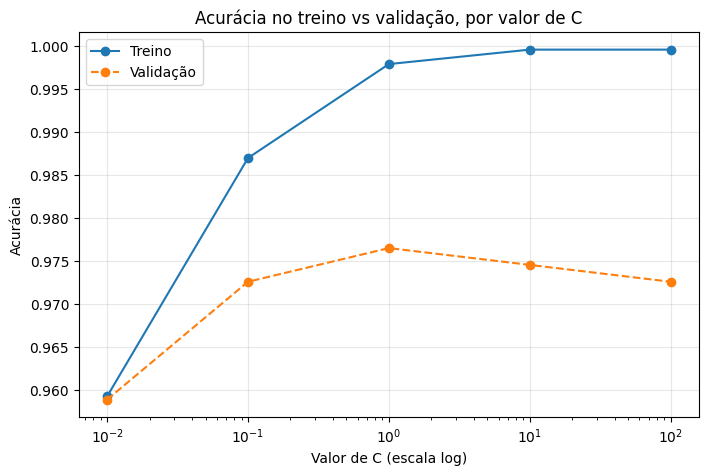

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(valores_C, scores_treino, marker='o', color='#1f77b4', label='Treino')

plt.plot(valores_C, scores_val, marker='o', color='#ff7f0e', linestyle='--', label='Validação')

plt.xscale('log')

plt.xlabel('Valor de C (escala log)')
plt.ylabel('Acurácia')
plt.title('Acurácia no treino vs validação, por valor de C')
plt.legend()
plt.grid(alpha=0.3)
plt.show()



In [66]:
y_teste_previsto = modelo_svm.predict(X_teste_tfidf)


In [67]:
print(classification_report(y_teste, y_teste_previsto, target_names=['Legitimate', 'Smishing']))


              precision    recall  f1-score   support

  Legitimate       0.98      0.98      0.98       301
    Smishing       0.98      0.97      0.97       209

    accuracy                           0.98       510
   macro avg       0.98      0.98      0.98       510
weighted avg       0.98      0.98      0.98       510



In [68]:
import joblib

joblib.dump(modelo_svm, 'modelo_svm_golpe.pkl')

joblib.dump(vetorizador, 'vetorizador_tfidf.pkl')


['vetorizador_tfidf.pkl']